In [1]:
import numpy as np
import matplotlib.pyplot as plt

from pimcs.operators import destroy, jspin
from pimcs.dicke import Dicke, ground
from pimcs.mcsolve import mcsolve

# setup system in exactly same way as with qutip.piqs
N = 500
OmegaC = 1.0
OmegaA = 0.5
Coupling = 0.9 / np.sqrt(N)

a = destroy(4) # increase cavity truncation if needed (varies depending on problem)
               # if unsure, set higher at small N, then keep decreasing if results do not change,
               # then keep it at this value for large N - should not need to grow with N.
Jx, Jy, Jz = jspin(N)

# one can also use spin-lowering and -raising operators
# Jp = jspin(N, '+')
# Jm = jspin(N, '-')

# Example: Dicke Model
H = OmegaC * a.dag()*a + OmegaA * 2*Jz + Coupling * 2*Jx * (a.dag() + a)

# construct system in the same way, now with cavity loss for (a),
# cavity_emission for (a†σ-) and cavity_absorption for (aσ+)
system = Dicke(N, H, cavity_loss = 1.0, emission = 0.2, dephasing = 0.0)

# construct initial state, can use dicke(j,m), ground(N), exicted(N)
# or rotated_qubit(N, θ) for (tensorproduct)_i  exp(-i θ/2 σx) |up>_i

psi0 = ground(N)
times = np.linspace(0, 40, 300)

# similar interface to qutip.mcsolve
# IMPORTANT: decrease jtol to improve the accuracy of trajectories
# (a value of ~0.01 works well for transient superradiance & Tavis-Cummings)
# IMPORTANT: a low number of trajectories (~25) is usually sufficient for large N
data = mcsolve(system, psi0, times, [a.dag()*a, a, Jz], ntraj = 200, ncpu = 8, jtol = 0.05)

Building optimized executable...
Running trajectories...


Trajectory [1/200] completed in 0.801 seconds.
Trajectory [2/200] completed in 0.819 seconds.
Trajectory [3/200] completed in 0.820 seconds.
Trajectory [4/200] completed in 0.835 seconds.
Trajectory [5/200] completed in 0.848 seconds.
Trajectory [6/200] completed in 0.852 seconds.
Trajectory [7/200] completed in 0.855 seconds.
Trajectory [8/200] completed in 0.876 seconds.
Trajectory [9/200] completed in 0.799 seconds.
Trajectory [10/200] completed in 0.797 seconds.
Trajectory [11/200] completed in 0.869 seconds.
Trajectory [12/200] completed in 0.920 seconds.
Trajectory [13/200] completed in 0.870 seconds.
Trajectory [14/200] completed in 0.945 seconds.
Trajectory [15/200] completed in 0.889 seconds.
Trajectory [16/200] completed in 0.981 seconds.
Trajectory [17/200] completed in 0.805 seconds.
Trajectory [18/200] completed in 0.854 seconds.
Trajectory [19/200] completed in 0.795 seconds.
Trajectory [20/200] completed in 0.872 seconds.
Trajectory [21/200] completed in 0.851 seconds.
T

Steady state photon count per emitter: 0.305


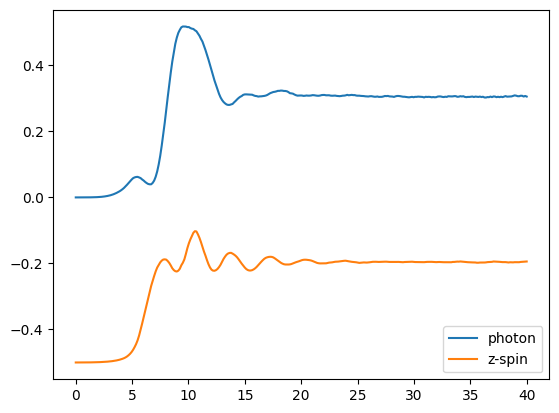

In [2]:
# obtain expectation values the same way as from qutip
# these are all complex for now: smarter Hermitian detection will come later

photon = data.expect[0].real
spin = data.expect[2].real

plt.plot(times, photon / N, label = "photon")
plt.plot(times, spin / N, label = "z-spin")
plt.legend(loc = "lower right")

steady_state_photon = np.mean(photon[times > 30]) / N
print(f"Steady state photon count per emitter: {steady_state_photon:.3f}")